In [ ]:
import pandas as pd 
import matplotlib.pyplot as plt 
import numpy
import seaborn as sns

In [3]:
pd.set_option("display.max_columns" , None )
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

In [5]:
df = pd.read_csv("../data/processed/clean_supply_chain.csv")
df.head()


,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Name,Customer City,Customer Country,Customer Segment,Customer State,Customer Zipcode,Department Name,Latitude,Longitude,Market,Order City,Order Country,order date (DateOrders),Order Item Discount,Order Item Discount Rate,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Region,Order State,Order Status,Order Zipcode,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,Sporting Goods,Caguas,Puerto Rico,Consumer,PR,725.0,Fitness,18.251453,-66.037056,Pacific Asia,Bekasi,Indonesia,1/31/2018 22:56,13.110000,0.04,327.75,0.29,1,327.75,314.640015,91.250000,Southeast Asia,Java Occidental,COMPLETE,59405.0,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,Sporting Goods,Caguas,Puerto Rico,Consumer,PR,725.0,Fitness,18.279451,-66.037064,Pacific Asia,Bikaner,India,1/13/2018 12:27,16.389999,0.05,327.75,-0.80,1,327.75,311.359985,-249.089996,South Asia,Rajastán,PENDING,59405.0,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,Sporting Goods,San Jose,EE. UU.,Consumer,CA,95125.0,Fitness,37.292233,-121.881279,Pacific Asia,Bikaner,India,1/13/2018 12:06,18.030001,0.06,327.75,-0.80,1,327.75,309.720001,-247.779999,South Asia,Rajastán,CLOSED,59405.0,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,Sporting Goods,Los Angeles,EE. UU.,Home Office,CA,90027.0,Fitness,34.125946,-118.291016,Pacific Asia,Townsville,Australia,1/13/2018 11:45,22.940001,0.07,327.75,0.08,1,327.75,304.809998,22.860001,Oceania,Queensland,COMPLETE,59405.0,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,Sporting Goods,Caguas,Puerto Rico,Corporate,PR,725.0,Fitness,18.253769,-66.037048,Pacific Asia,Townsville,Australia,1/13/2018 11:24,29.500000,0.09,327.75,0.45,1,327.75,298.250000,134.210007,Oceania,Queensland,PENDING_PAYMENT,59405.0,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 37 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  str    
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Benefit per order              180519 non-null  float64
 4   Sales per customer             180519 non-null  float64
 5   Delivery Status                180519 non-null  str    
 6   Late_delivery_risk             180519 non-null  int64  
 7   Category Name                  180519 non-null  str    
 8   Customer City                  180519 non-null  str    
 9   Customer Country               180519 non-null  str    
 10  Customer Segment               180519 non-null  str    
 11  Customer State                 180519 non-null  str    
 12  Customer Zipcode               180519 non

In [10]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Days for shipping (real),180519.0,3.497654,1.623722,0.000000,2.000000,3.000000,5.000000,6.000000
Days for shipment (scheduled),180519.0,2.931847,1.374449,0.000000,2.000000,4.000000,4.000000,4.000000
Benefit per order,180519.0,21.974989,104.433526,-4274.979980,7.000000,31.520000,64.800003,911.799988
Sales per customer,180519.0,183.107609,120.043670,7.490000,104.379997,163.990005,247.399994,1939.989990
Late_delivery_risk,180519.0,0.548291,0.497664,0.000000,0.000000,1.000000,1.000000,1.000000
Customer Zipcode,180519.0,35920.852021,37542.209723,603.000000,725.000000,19380.000000,78207.000000,99205.000000
Latitude,180519.0,29.719955,9.813646,-33.937553,18.265432,33.144863,39.279617,48.781933
Longitude,180519.0,-84.915675,21.433241,-158.025986,-98.446312,-76.847908,-66.370583,115.263077
Order Item Discount,180519.0,20.664741,21.800901,0.000000,5.400000,14.000000,29.990000,500.000000
Order Item Discount Rate,180519.0,0.101668,0.070415,0.000000,0.040000,0.100000,0.160000,0.250000


In [11]:
df.describe(include="object").T

/var/folders/sp/7nykhmgx2_5b0j0zvl3pjy_80000gn/T/ipykernel_31917/1274302342.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object").T


,count,unique,top,freq
Type,180519,4,DEBIT,69295
Delivery Status,180519,4,Late delivery,98977
Category Name,180519,50,Cleats,24551
Customer City,180519,563,Caguas,66770
Customer Country,180519,2,EE. UU.,111146
Customer Segment,180519,3,Consumer,93504
Customer State,180519,46,PR,69373
Department Name,180519,11,Fan Shop,66861
Market,180519,5,LATAM,51594
Order City,180519,3597,Santo Domingo,2211


In [13]:
df["Late_delivery_risk"].value_counts(normalize=True) * 100

Late_delivery_risk
1    54.829132
0    45.170868
Name: proportion, dtype: float64

In [14]:
missing = df.isnull().sum()

missing = missing[missing > 0]

missing

Series([], dtype: int64)

In [19]:
shipping_delay = pd.crosstab(
    df["Shipping Mode"],
    df["Late_delivery_risk"],
    normalize="index"
)

shipping_delay

Late_delivery_risk,0,1
Shipping Mode,,
First Class,0.046775,0.953225
Same Day,0.542570,0.457430
Second Class,0.233672,0.766328
Standard Class,0.619283,0.380717


In [21]:
market_delay = pd.crosstab(
    df["Market"],
    df["Late_delivery_risk"],
    normalize="index"
)

market_delay

Late_delivery_risk,0,1
Market,,
Africa,0.454107,0.545893
Europe,0.447922,0.552078
LATAM,0.456448,0.543552
Pacific Asia,0.449540,0.550460
USCA,0.451994,0.548006


In [22]:
segment_delay = pd.crosstab(
    df["Customer Segment"],
    df["Late_delivery_risk"],
    normalize="index"
)

segment_delay

Late_delivery_risk,0,1
Customer Segment,,
Consumer,0.451916,0.548084
Corporate,0.452773,0.547227
Home Office,0.449296,0.550704


/var/folders/sp/7nykhmgx2_5b0j0zvl3pjy_80000gn/T/ipykernel_31917/3063712023.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


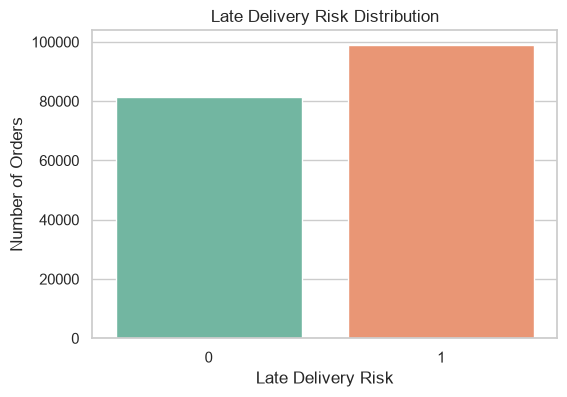

In [28]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="Late_delivery_risk",
    palette="Set2"
)

plt.title("Late Delivery Risk Distribution")

plt.xlabel("Late Delivery Risk")

plt.ylabel("Number of Orders")

plt.show()

In [29]:
(df["Late_delivery_risk"].value_counts(normalize=True) * 100).round(2)

Late_delivery_risk
1    54.83
0    45.17
Name: proportion, dtype: float64

In [30]:
shipping_delay = pd.crosstab(
    df["Shipping Mode"],
    df["Late_delivery_risk"],
    normalize="index"
)

shipping_delay

Late_delivery_risk,0,1
Shipping Mode,,
First Class,0.046775,0.953225
Same Day,0.542570,0.457430
Second Class,0.233672,0.766328
Standard Class,0.619283,0.380717


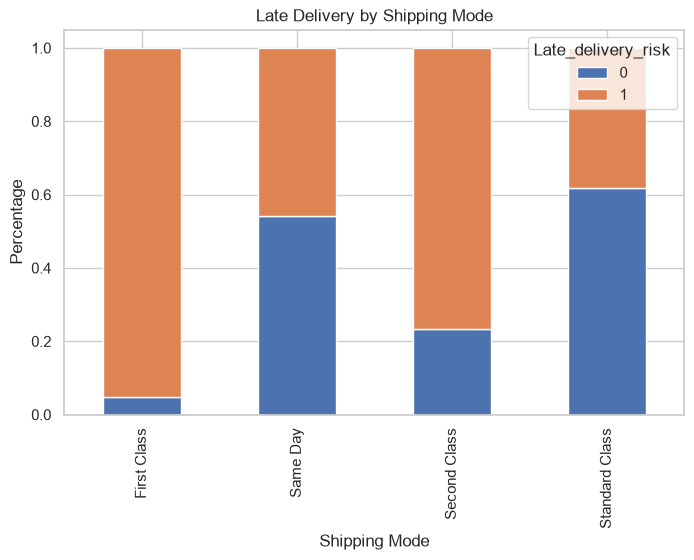

In [31]:
shipping_delay.plot(
    kind="bar",
    stacked=True,
    figsize=(8,5)
)

plt.title("Late Delivery by Shipping Mode")

plt.ylabel("Percentage")

plt.show()

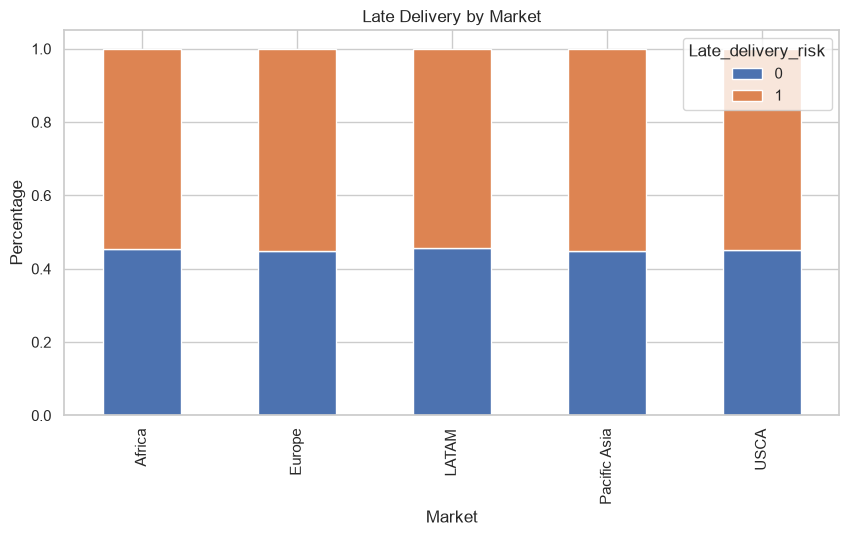

In [33]:
market_delay.plot(
    kind="bar",
    stacked=True,
    figsize=(10,5)
)

plt.title("Late Delivery by Market")

plt.ylabel("Percentage")

plt.show()

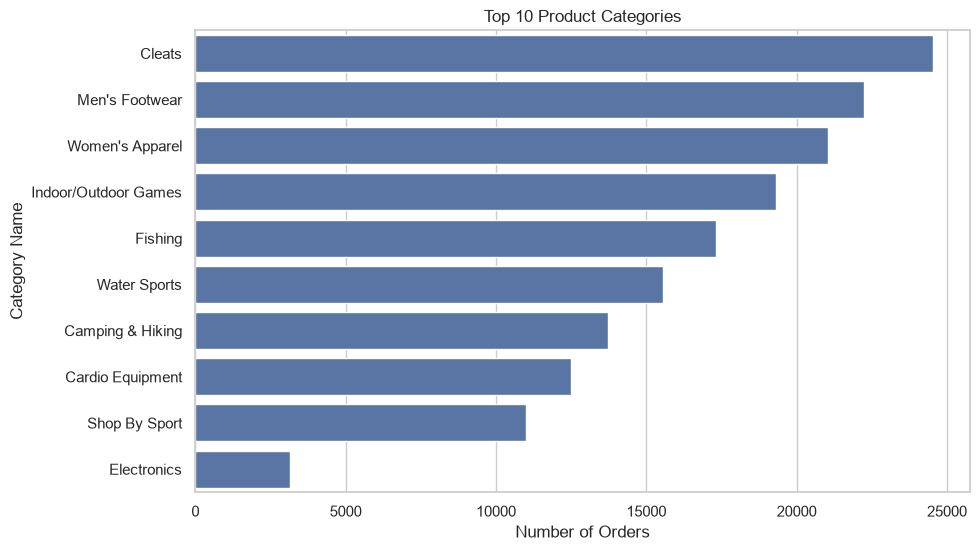

In [36]:
top_categories = df["Category Name"].value_counts().head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_categories.values,
    y=top_categories.index
)

plt.title("Top 10 Product Categories")

plt.xlabel("Number of Orders")

plt.show()

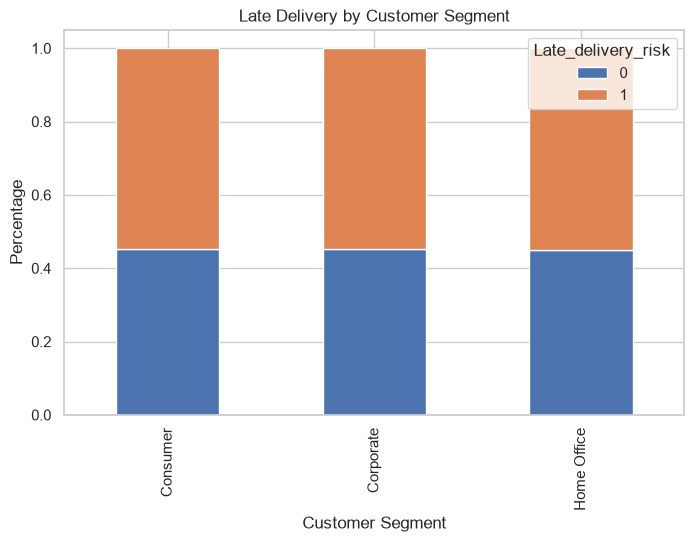

In [35]:
segment_delay.plot(
    kind="bar",
    stacked=True,
    figsize=(8,5)
)

plt.title("Late Delivery by Customer Segment")

plt.ylabel("Percentage")

plt.show()

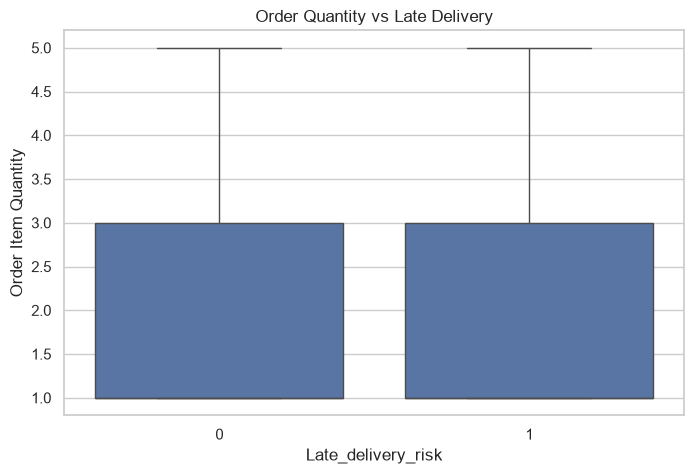

In [37]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Late_delivery_risk",
    y="Order Item Quantity"
)

plt.title("Order Quantity vs Late Delivery")

plt.show()

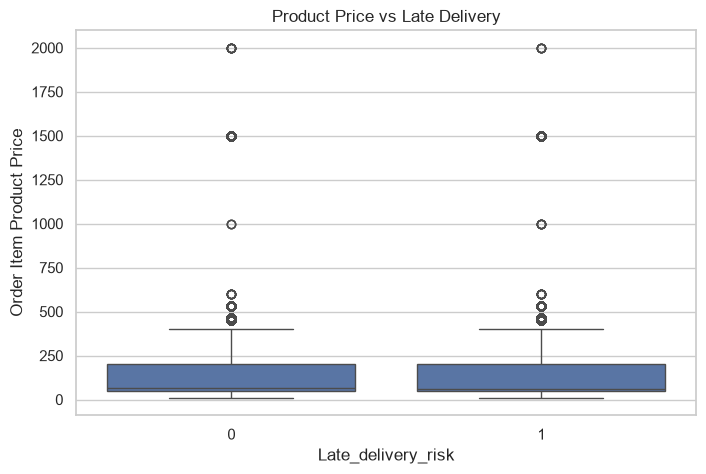

In [38]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Late_delivery_risk",
    y="Order Item Product Price"
)

plt.title("Product Price vs Late Delivery")

plt.show()

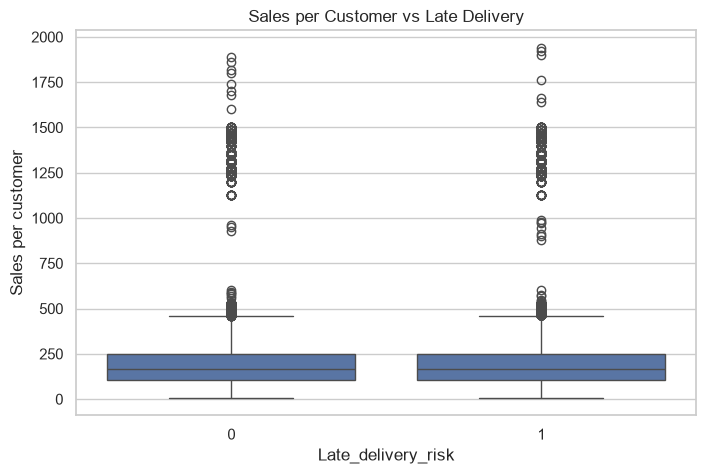

In [39]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Late_delivery_risk",
    y="Sales per customer"
)

plt.title("Sales per Customer vs Late Delivery")

plt.show()

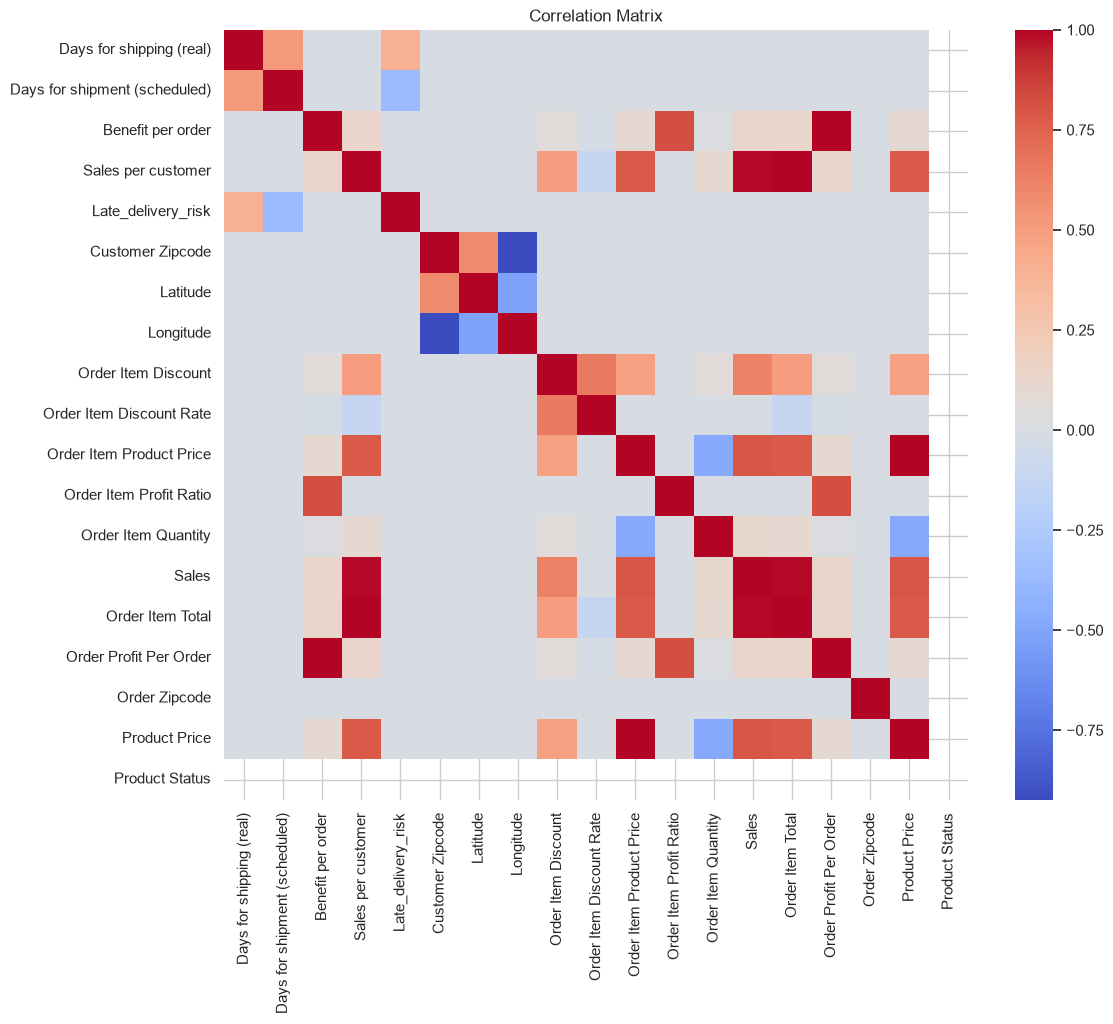

In [40]:
numeric_df = df.select_dtypes(include=["number"])

plt.figure(figsize=(12,10))

sns.heatmap(
    numeric_df.corr(),
    cmap="coolwarm",
    annot=False
)

plt.title("Correlation Matrix")

plt.show()

In [41]:
df.isnull().sum().sort_values(ascending=False)

Type                             0
order date (DateOrders)          0
Order Item Discount Rate         0
Order Item Product Price         0
Order Item Profit Ratio          0
Order Item Quantity              0
Sales                            0
Order Item Total                 0
Order Profit Per Order           0
Order Region                     0
Order State                      0
Order Status                     0
Order Zipcode                    0
Product Name                     0
Product Price                    0
Product Status                   0
shipping date (DateOrders)       0
Order Item Discount              0
Order Country                    0
Days for shipping (real)         0
Order City                       0
Days for shipment (scheduled)    0
Benefit per order                0
Sales per customer               0
Delivery Status                  0
Late_delivery_risk               0
Category Name                    0
Customer City                    0
Customer Country    